In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_excel('coffee_sales_Project 1.xlsx')

In [ ]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


### DATA Exploring

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


In [ ]:
df['transaction_time'].unique()

array([datetime.time(7, 6, 11), datetime.time(7, 8, 56),
       datetime.time(7, 14, 4), ..., datetime.time(10, 34, 30),
       datetime.time(12, 3, 24), datetime.time(16, 59, 49)], dtype=object)

In [ ]:
df['transaction_time']=pd.to_datetime(df['transaction_time'], format='%H:%M:%S')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  datetime64[ns]
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](2), float64(1), int64(4), object(4)
memory usage: 12.5+ MB


In [ ]:
df.head(1)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg


In [ ]:
df[df['transaction_date'].isna()]

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail


In [ ]:
df['product_detail'].isna().any()

False

In [ ]:
df.sample(100)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
29548,29605,2023-02-21,1900-01-01 18:32:44,2,3,Astoria,64,0.80,Flavours,Regular syrup,Hazelnut syrup
23364,23421,2023-02-11,1900-01-01 13:10:30,2,3,Astoria,52,2.50,Tea,Brewed Chai tea,Traditional Blend Chai Rg
125233,125570,2023-06-10,1900-01-01 18:46:20,1,8,Hell's Kitchen,65,0.80,Flavours,Sugar free syrup,Sugar Free Vanilla syrup
68639,68809,2023-04-17,1900-01-01 08:09:34,3,5,Lower Manhattan,38,3.75,Coffee,Barista Espresso,Latte
48141,48248,2023-03-21,1900-01-01 16:51:49,1,3,Astoria,34,2.45,Coffee,Premium brewed coffee,Jamaican Coffee River Sm
...,...,...,...,...,...,...,...,...,...,...,...
95865,96119,2023-05-15,1900-01-01 10:34:58,1,8,Hell's Kitchen,71,3.75,Bakery,Pastry,Chocolate Croissant
63288,63458,2023-04-11,1900-01-01 07:58:39,1,3,Astoria,56,2.55,Tea,Brewed Chai tea,Spicy Eye Opener Chai Rg
60132,60302,2023-04-07,1900-01-01 11:30:40,1,5,Lower Manhattan,58,3.50,Drinking Chocolate,Hot chocolate,Dark chocolate Rg
19638,19668,2023-02-05,1900-01-01 08:50:22,2,8,Hell's Kitchen,43,3.00,Tea,Brewed herbal tea,Lemon Grass Lg


### Spliting The Values like Lg,Sm & Rg

In [ ]:
df['Size_Code'] = df['product_detail'].str.split().str[-1]


In [ ]:
df.head(3)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Size_Code
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,Rg
1,2,2023-01-01,1900-01-01 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,Lg
2,3,2023-01-01,1900-01-01 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,Lg


In [ ]:
size_map={
    'Lg':'Large',
    'Sm':'Small',
    'Rg':'Regular'
}
df['Coffee_Size']=df['Size_Code'].map(size_map).fillna('Not Define')

In [ ]:
df.head(2)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Size_Code,Coffee_Size
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,Rg,Regular
1,2,2023-01-01,1900-01-01 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,Lg,Large


# Removing Unnecessary Columns

In [ ]:
df = df.drop(columns=['Size_Code'])

In [ ]:
df.head(2)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Coffee_Size
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,Regular
1,2,2023-01-01,1900-01-01 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,Large


# Removing the Value like Rg,Lg & Sm in the Column of Product details

In [ ]:
sizes = ['Lg', 'Rg', 'Sm']
df['product_detail'] = df['product_detail'].apply(
    lambda x: ' '.join(x.split()[:-1]) if x.split()[-1] in sizes else x
)


In [ ]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Coffee_Size
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia,Regular
1,2,2023-01-01,1900-01-01 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai,Large
2,3,2023-01-01,1900-01-01 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate,Large
3,4,2023-01-01,1900-01-01 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend,Small
4,5,2023-01-01,1900-01-01 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai,Large


In [ ]:
df['time_only'] = pd.to_timedelta(pd.to_datetime(df['transaction_time']).dt.strftime("%H:%M:%S"))


In [ ]:
df.head(1)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Coffee_Size,time_only
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia,Regular,0 days 07:06:11


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype          
---  ------            --------------   -----          
 0   transaction_id    149116 non-null  int64          
 1   transaction_date  149116 non-null  datetime64[ns] 
 2   transaction_time  149116 non-null  datetime64[ns] 
 3   transaction_qty   149116 non-null  int64          
 4   store_id          149116 non-null  int64          
 5   store_location    149116 non-null  object         
 6   product_id        149116 non-null  int64          
 7   unit_price        149116 non-null  float64        
 8   product_category  149116 non-null  object         
 9   product_type      149116 non-null  object         
 10  product_detail    149116 non-null  object         
 11  Coffee_Size       149116 non-null  object         
 12  time_only         149116 non-null  timedelta64[ns]
dtypes: datetime64[ns](2), float64(1), int64(4), 

In [ ]:
df['time_only'] = pd.to_timedelta(pd.to_datetime(df['transaction_time']).dt.strftime("%H:%M:%S"))


In [ ]:
df.head(1)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Coffee_Size,time_only
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia,Regular,0 days 07:06:11


In [ ]:
df['time_only']=df['time_only'].astype(str).str.replace("0 day","",regex=False)

In [ ]:
df.head(2)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Coffee_Size,time_only
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia,Regular,s 07:06:11
1,2,2023-01-01,1900-01-01 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai,Large,s 07:08:56


In [ ]:
df['time_only']=df['time_only'].astype(str).str.replace("s","",regex=False)

In [ ]:
df.head(2)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Coffee_Size,time_only
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia,Regular,07:06:11
1,2,2023-01-01,1900-01-01 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai,Large,07:08:56


In [ ]:
df['product_category'].unique()

array(['Coffee', 'Tea', 'Drinking Chocolate', 'Bakery', 'Flavours',
       'Loose Tea', 'Coffee beans', 'Packaged Chocolate', 'Branded'],
      dtype=object)

In [ ]:
df['transaction_date'].unique()

<DatetimeArray>
['2023-01-01 00:00:00', '2023-01-02 00:00:00', '2023-01-03 00:00:00',
 '2023-01-04 00:00:00', '2023-01-05 00:00:00', '2023-01-06 00:00:00',
 '2023-01-07 00:00:00', '2023-01-08 00:00:00', '2023-01-09 00:00:00',
 '2023-01-10 00:00:00',
 ...
 '2023-06-21 00:00:00', '2023-06-22 00:00:00', '2023-06-23 00:00:00',
 '2023-06-24 00:00:00', '2023-06-25 00:00:00', '2023-06-26 00:00:00',
 '2023-06-27 00:00:00', '2023-06-28 00:00:00', '2023-06-29 00:00:00',
 '2023-06-30 00:00:00']
Length: 181, dtype: datetime64[ns]

In [ ]:
df['transaction_date'] = pd.to_datetime(df['transaction_date']).dt.date


In [ ]:
df.head(2)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Coffee_Size,time_only
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia,Regular,07:06:11
1,2,2023-01-01,1900-01-01 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai,Large,07:08:56


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  object        
 2   transaction_time  149116 non-null  datetime64[ns]
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
 11  Coffee_Size       149116 non-null  object        
 12  time_only         149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(7)
memor

In [ ]:
df['transaction_date'] = pd.to_datetime(df['transaction_date']).dt.normalize()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  datetime64[ns]
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
 11  Coffee_Size       149116 non-null  object        
 12  time_only         149116 non-null  object        
dtypes: datetime64[ns](2), float64(1), int64(4), object(6)
memor

# Features Engineering (Creating New Column That is Total Bills)

In [ ]:
df['Total_Bills']=df['transaction_qty']*df['unit_price']

In [ ]:
df.head(1)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Coffee_Size,time_only,Total_Bills
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia,Regular,07:06:11,6.0


In [ ]:
df['time_only'] = pd.to_datetime(df['time_only'].str.strip(), format='%H:%M:%S')
df['Hour'], df['Minute'] = df['time_only'].dt.hour, df['time_only'].dt.minute


In [ ]:
df.head(1)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Coffee_Size,time_only,Total_Bills,Hour,Minute
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia,Regular,1900-01-01 07:06:11,6.0,7,6


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  datetime64[ns]
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
 11  Coffee_Size       149116 non-null  object        
 12  time_only         149116 non-null  datetime64[ns]
 13  Total_Bills       149116 non-null  float64       
 14  Hour

# DATA VISUALIZATION

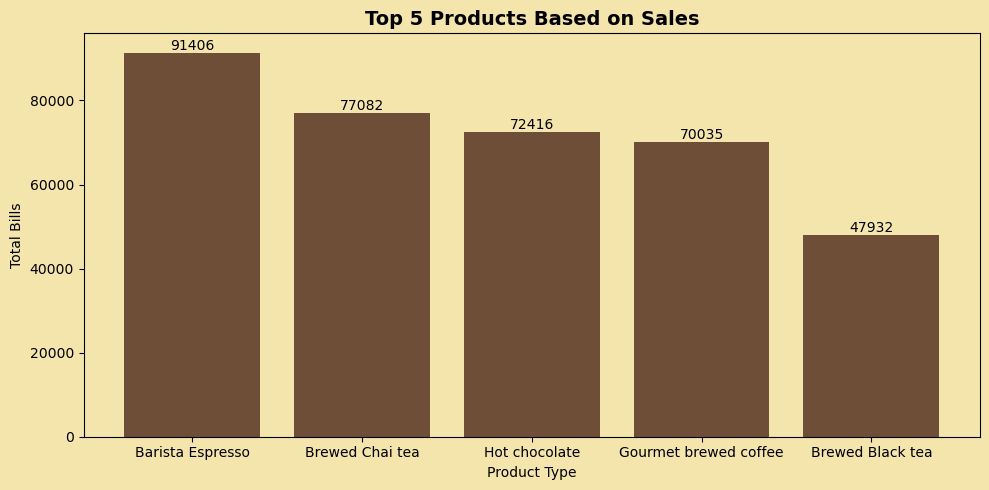

In [ ]:
df['Total_Bills'] = pd.to_numeric(df['Total_Bills'], errors='coerce')
df = df.dropna(subset=['Total_Bills'])
top5 = (
    df.groupby('product_type', as_index=False)['Total_Bills']
      .sum()
      .sort_values(by='Total_Bills', ascending=False)
      .head(5)
)
plt.figure(figsize=(10, 5))
bar_color = '#6F4E37'       # dark coffee
bg_color = '#F3E5AB'        # light coffee
x = range(len(top5))
plt.bar(x, top5['Total_Bills'], color=bar_color)
for i, value in enumerate(top5['Total_Bills']):
    plt.text(i, value, f"{value:.0f}", ha='center', va='bottom', fontsize=10)
    
plt.title('Top 5 Products Based on Sales', fontsize=14, fontweight='bold')
plt.xlabel('Product Type')
plt.ylabel('Total Bills')
plt.xticks(x, top5['product_type'])
plt.gca().set_facecolor(bg_color)
plt.gcf().set_facecolor(bg_color)
plt.tight_layout()
plt.show()


In [ ]:
df.head(1)


,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Coffee_Size,time_only,Total_Bills,Hour,Minute
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia,Regular,1900-01-01 07:06:11,6.0,7,6


# BAR CHARTS

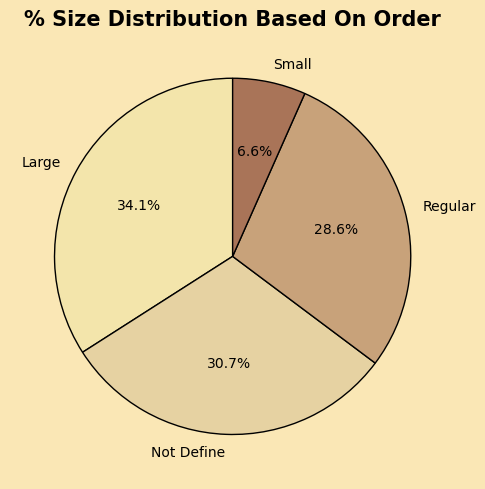

In [ ]:
grp = df.groupby('Coffee_Size')['Total_Bills'].sum().reset_index()
labels = grp['Coffee_Size']
sizes = grp['Total_Bills']
coffee_colors = [
    '#F3E5AB',  # Latte Foam
    '#E6D2A2',  # Caramel Latte
    '#C8A27A',  # Cappuccino
    '#A97458',  # Mocha
    '#7B4F34',  # Coffee Bean
    '#4B2E15'   # Espresso
][:len(labels)]
plt.figure(figsize=(5, 7), facecolor='#FAE7B5')
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=coffee_colors,wedgeprops={'edgecolor': 'black'})
plt.title('% Size Distribution Based On Order', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


# CREATING New column that is Month

In [ ]:
# Convert to datetime (if not already)
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Create Month Name column
df['Month'] = df['transaction_date'].dt.strftime('%B')


In [ ]:
df.head(1)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Coffee_Size,time_only,Total_Bills,Hour,Minute,Month
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia,Regular,1900-01-01 07:06:11,6.0,7,6,January


# Line Charts

C:\Users\sanja\AppData\Local\Temp\ipykernel_2820\3656220202.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby('Month', as_index=False)['Total_Bills'].sum()


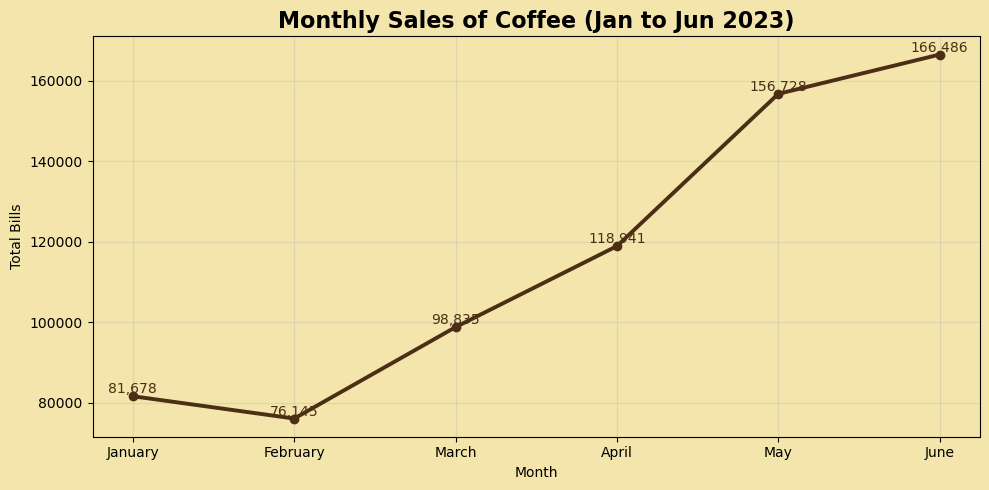

In [ ]:
month_order = ["January", "February", "March", "April", "May", "June"]
df['Month'] = df['Month'].str.strip().str.title()
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)
df['Total_Bills'] = pd.to_numeric(df['Total_Bills'], errors='coerce')
grp = df.groupby('Month', as_index=False)['Total_Bills'].sum()
grp = grp.dropna(subset=['Month'])   # removes invalid months
coffee_color = '#4B2E15'
background = '#F3E5AB'
plt.figure(figsize=(10, 5), facecolor=background)
ax = plt.gca()
ax.set_facecolor(background)
x_pos = range(len(grp['Month']))
plt.plot(x_pos, grp['Total_Bills'], marker='o', linewidth=2.8, color=coffee_color)
for x, y in zip(x_pos, grp['Total_Bills']):
    plt.text(x, y, f"{y:,.0f}", ha='center', va='bottom', fontsize=10, color=coffee_color)
plt.xticks(x_pos, grp['Month'])   # show month names
plt.title("Monthly Sales of Coffee (Jan to Jun 2023)", fontsize=16, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Total Bills")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
df.head(2)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Coffee_Size,time_only,Total_Bills,Hour,Minute,Month
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia,Regular,1900-01-01 07:06:11,6.0,7,6,January
1,2,2023-01-01,1900-01-01 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai,Large,1900-01-01 07:08:56,6.2,7,8,January


In [ ]:
df.head(2)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Coffee_Size,time_only,Total_Bills,Hour,Minute,Month
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia,Regular,1900-01-01 07:06:11,6.0,7,6,January
1,2,2023-01-01,1900-01-01 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai,Large,1900-01-01 07:08:56,6.2,7,8,January


In [ ]:
df['store_location'].unique()

array(['Lower Manhattan', "Hell's Kitchen", 'Astoria'], dtype=object)

# DONUT CHARTS

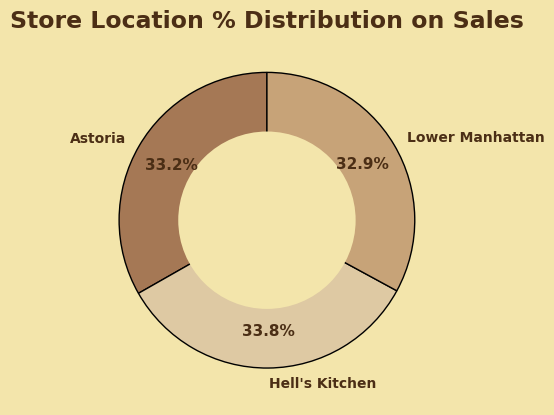

In [ ]:
grp = df.groupby('store_location')['Total_Bills'].sum().reset_index()
labels = grp['store_location']
sizes = grp['Total_Bills']
coffee_colors = [
    '#F3E5AB',  
    '#DEC9A3',
    '#C7A378'
]
dark_astoria_color = '#A57855'   # choose any darker shade
astoria_index = labels[labels == "Astoria"].index[0]
coffee_colors[astoria_index] = dark_astoria_color
plt.figure(figsize=(5, 8), facecolor='#F3E5AB')
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=coffee_colors,
    pctdistance=0.75,
    labeldistance=1.1,
    wedgeprops={'edgecolor': 'black'}
)
centre_circle = plt.Circle((0, 0), 0.60, fc='#F3E5AB')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
for autotext in autotexts:
    autotext.set_color('#4B2E15')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)
for text in texts:
    text.set_color('#4B2E15')
    text.set_fontweight('bold')
    text.set_fontsize(10)
plt.title("Store Location % Distribution on Sales",
          fontsize=17,
          fontweight='bold',
          color='#4B2E15')
plt.tight_layout()
plt.show()


In [ ]:
df.head(1)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Coffee_Size,time_only,Total_Bills,Hour,Minute,Month
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia,Regular,1900-01-01 07:06:11,6.0,7,6,January


In [ ]:
df['product_category'].unique()

array(['Coffee', 'Tea', 'Drinking Chocolate', 'Bakery', 'Flavours',
       'Loose Tea', 'Coffee beans', 'Packaged Chocolate', 'Branded'],
      dtype=object)

# Cluster Bar Chart

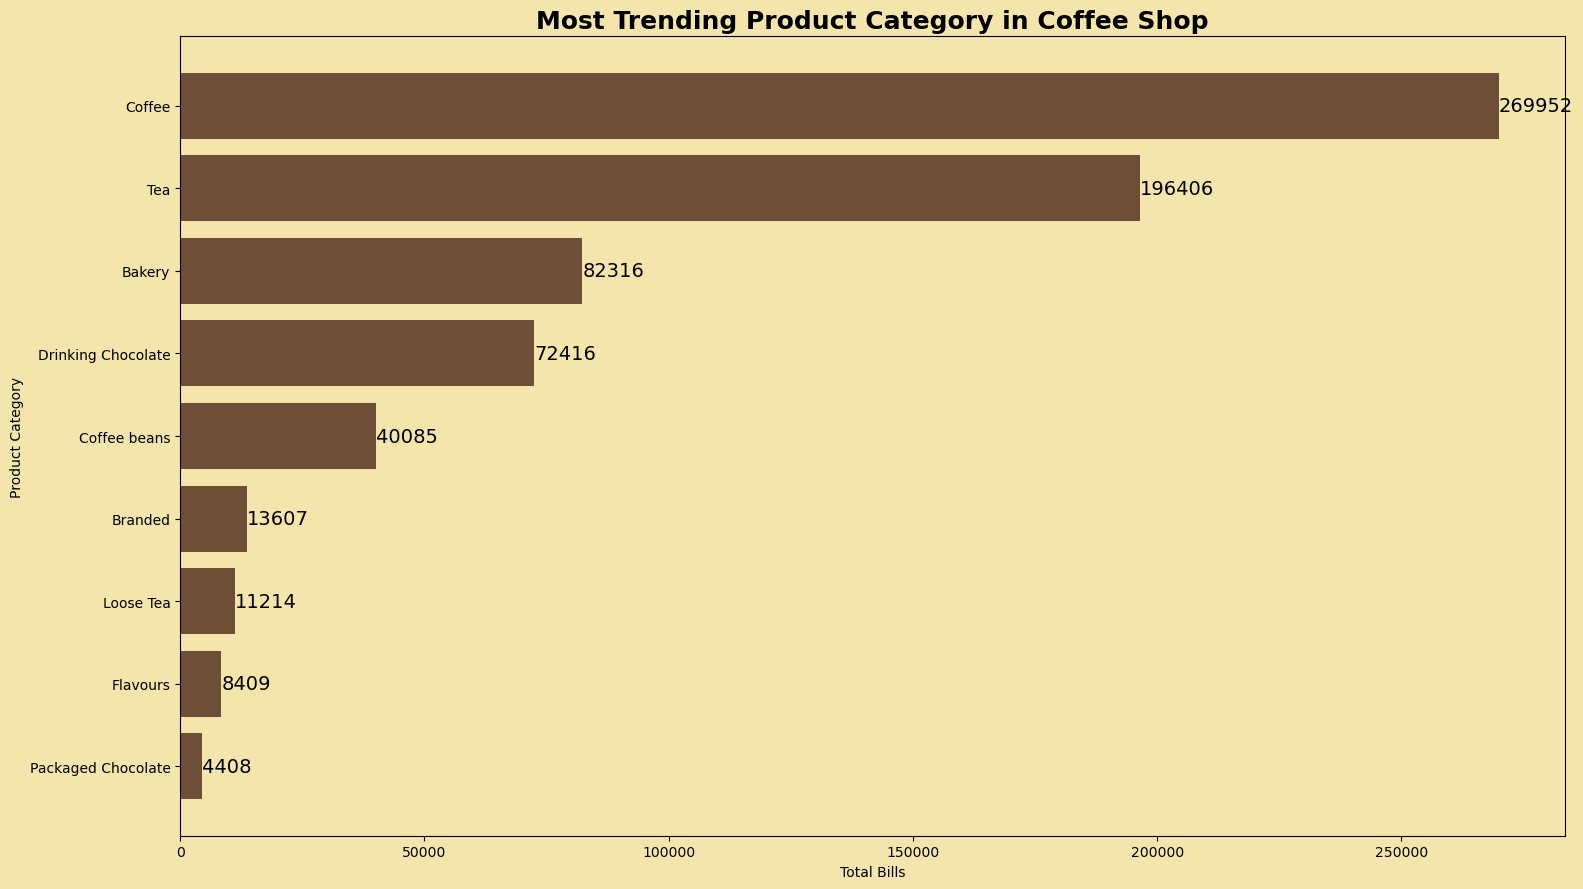

In [ ]:
prod_category = (df.groupby('product_category', as_index=False)['Total_Bills'].sum().sort_values(by='Total_Bills', ascending=True))
plt.figure(figsize=(16,9))
bar_color = '#6F4E37'
bg_color = '#F3E5AB'
plt.barh(prod_category['product_category'], prod_category['Total_Bills'], color=bar_color)
for index, value in enumerate(prod_category['Total_Bills']):
    plt.text(value, index, f"{value:.0f}", va='center', ha='left', fontsize=14)
plt.title('Most Trending Product Category in Coffee Shop',
          fontsize=18, fontweight='bold')
plt.xlabel('Total Bills')
plt.ylabel('Product Category')
plt.gca().set_facecolor(bg_color)
plt.gcf().set_facecolor(bg_color)
plt.tight_layout()
plt.show()


# Removing the Column of 'Time Only'

In [ ]:
df.head(1)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Coffee_Size,time_only,Total_Bills,Hour,Minute,Month
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia,Regular,1900-01-01 07:06:11,6.0,7,6,January


In [ ]:
df['transaction_time'] = pd.to_datetime(df['transaction_time']).dt.strftime('%H:%M:%S')


In [ ]:
df.head(1)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Coffee_Size,time_only,Total_Bills,Hour,Minute,Month
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia,Regular,1900-01-01 07:06:11,6.0,7,6,January


In [ ]:
df=df.drop(columns=['time_only'])

In [ ]:
df.head(1)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,Coffee_Size,Total_Bills,Hour,Minute,Month
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia,Regular,6.0,7,6,January


# Conclusion

## Customer preference clearly leans toward Coffee and Tea, which dominate overall sales. Lower-performing categories offer opportunities for promotions or product improvement to enhance customer engagement.

In [ ]:
df.to_excel('clean_Coffee_data.xlsx')